# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax
from hgq.regularizers import MonoL1

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

I0000 00:00:1783393638.657663 2525911 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Constant for training quantizers bit-width optimizations
REGULARIZER = 1e-5

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
# BetaPID dynamically adjusts beta to steer the model toward a target EBOPs budget.
callbacks = get_callbacks(
    model_name='qat',
    patience=30,
    track_ebops=True,
    target_ebops=800_000,
    init_beta=1e-7,
)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - FreeEBOPs
  - BetaPID


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [6]:
from hgq.constraints import MinMax, Max
from hgq.regularizers import MonoL1

with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        # bc=Max(6),
        # ic=Max(4),
        i0=2, b0=6,
        # br=MonoL1(REGULARIZER),
        # ir=MonoL1(REGULARIZER),
        default_q_type='kbi', overflow_mode='SAT_SYM'
    ),
    # QuantizerConfigScope(
    #     place='bias',
    #     # bc=Max(3),
    #     # ic=Max(3),
    #     i0=2, b0=4,
    #     # br=MonoL1(REGULARIZER),
    #     # ir=MonoL1(REGULARIZER),
    #     default_q_type='kbi', overflow_mode='SAT_SYM'
    # ),
    QuantizerConfigScope(
        place='datalane',
        # fc=Max(3),
        # ic=Max(6),
        i0=3, f0=3,
        heterogeneous_axis=(), # homogeneous_axis=(0,),
        # ir=MonoL1(REGULARIZER),
        # fr=MonoL1(REGULARIZER),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True),  # beta managed by BetaPID callback
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()

I0000 00:00:1783393641.918878 2525911 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1175 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 16)       │           646 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │         9,286 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        13,926 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (QMaxPooling2D)          │ (None, 1, 1, 24)       │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 12)             │         1,158 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 12)             │           126 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 24)             │         1,158 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 24)             │           246 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,858 (85.31 KB)

 Trainable params: 20,058 (78.35 KB)

 Non-trainable params: 6,800 (6.96 KB)

In [7]:
check_layer_trainable_params(model_qat)

qconv_1: 144
qconv_2: 2304
qconv_3: 3456
qdense_1: 288
bn_dense_1: 12
qdense_2: 288
bn_dense_2: 24
output: 72


### Training

Epoch 1/220


I0000 00:00:1783393648.584351 2525976 service.cc:153] XLA service 0x7f8a44053b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783393648.584366 2525976 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1783393648.802610 2525976 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783393649.791827 2525976 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1783393649.861917 2525976 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17840__.98


 3/59 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3340 - loss: 1.6612  

I0000 00:00:1783393661.667146 2525976 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4054 - loss: 1.4807 

I0000 00:00:1783393663.232784 2525976 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17840__.98
I0000 00:00:1783393667.263863 2526805 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_1', 152 bytes spill stores, 164 bytes spill loads



59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.4093 - loss: 1.4749

I0000 00:00:1783393672.417616 2525976 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion_1', 212 bytes spill stores, 232 bytes spill loads



59/59 ━━━━━━━━━━━━━━━━━━━━ 36s 305ms/step - accuracy: 0.4837 - loss: 1.3657 - val_accuracy: 0.3637 - val_loss: 1.3362 - learning_rate: 0.0010 - ebops: 3424564.0000 - beta: 1.0000e-07
Epoch 2/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6787 - loss: 1.0948 - val_accuracy: 0.3557 - val_loss: 1.8009 - learning_rate: 0.0010 - ebops: 3422404.0000 - beta: 1.0000e-07
Epoch 3/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7355 - loss: 1.0006 - val_accuracy: 0.6205 - val_loss: 0.9027 - learning_rate: 0.0010 - ebops: 3643588.0000 - beta: 1.0000e-07
Epoch 4/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7712 - loss: 0.9067 - val_accuracy: 0.6104 - val_loss: 0.8995 - learning_rate: 0.0010 - ebops: 3424708.0000 - beta: 1.0000e-07
Epoch 5/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7927 - loss: 0.8580 - val_accuracy: 0.5768 - val_loss: 1.0965 - learning_rate: 0.0010 - ebops: 3424276.0000 - beta: 1.0000e-07
Epoch 6/220
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

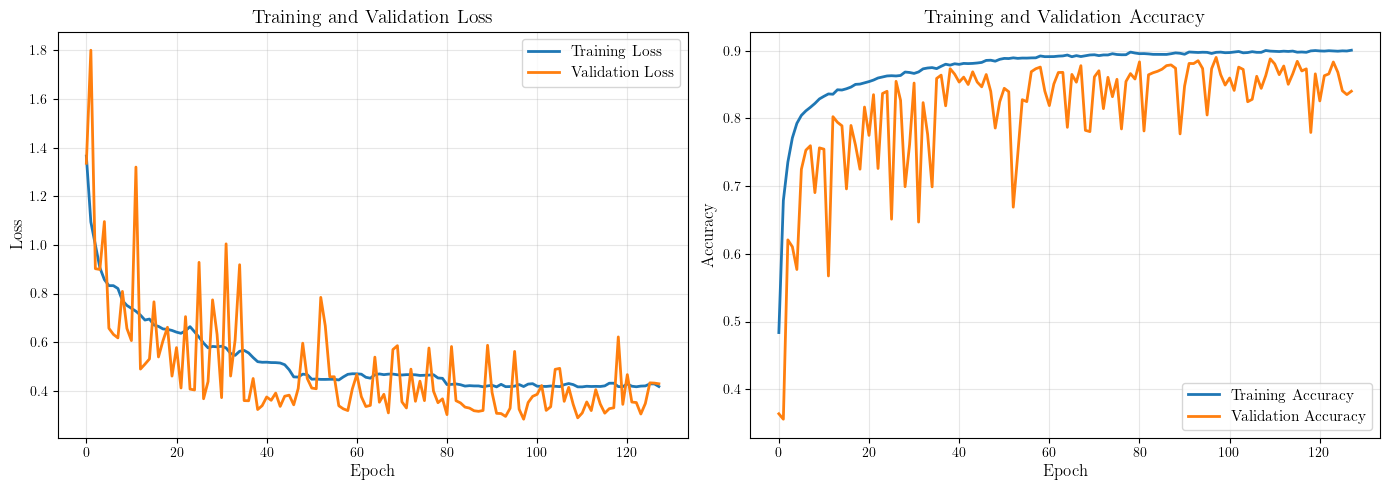

In [8]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=220) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation

In [9]:
class_report_metric(model_qat, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.2901
  Accuracy: 88.79%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.9264    0.8568    0.8902     40000
   lateral_R     0.8553    0.9215    0.8872     40000
      supine     0.8873    0.8854    0.8863     40001

    accuracy                         0.8879    120001
   macro avg     0.8897    0.8879    0.8879    120001
weighted avg     0.8897    0.8879    0.8879    120001



In [10]:
# Inspect learned quantization bit-widths
# bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


In [11]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048, reset=True)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 2089530 
LUTs: 1679763 
DSPs: 7450


In [12]:
## Determine accuracy of Keras model, for comparison
keras_score = model_qat.evaluate(X_test, y_test, verbose=0)

print("="*80)    
print("Keras  model evaluation \t Loss: {:.2f} \t Accuracy: {:.2f}%".format(keras_score[0], keras_score[1]*100))
print("="*80)

Keras  model evaluation 	 Loss: 0.29 	 Accuracy: 88.79%


In [13]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=7.00, fbits=7.00, type=kif
  kq: bits=6.06, fbits=7.06, type=kbi
  bq: bits=3.69, fbits=4.69, type=kbi

qconv_2 (QConv2D):
  iq: bits=7.00, fbits=7.00, type=kif
  kq: bits=5.15, fbits=6.15, type=kbi
  bq: bits=3.25, fbits=4.25, type=kbi

qconv_3 (QConv2D):
  iq: bits=7.00, fbits=7.00, type=kif
  kq: bits=5.15, fbits=6.15, type=kbi
  bq: bits=2.92, fbits=3.92, type=kbi
pool_3: QMaxPooling2D (no quantizers)
flatten: Flatten (no quantizers)

qdense_1 (QDense):
  iq: bits=10.00, fbits=10.00, type=kif
  kq: bits=5.59, fbits=6.59, type=kbi

bn_dense_1 (QBatchNormalization):
  iq: bits=11.00, fbits=12.00, type=kif
  kq: bits=7.17, fbits=8.17, type=kbi
  bq: bits=4.58, fbits=5.58, type=kbi
activation: Activation (no quantizers)

qdense_2 (QDense):
  iq: bits=8.00, fbits=8.00, type=kif
  kq: bits=6.00, fbits=7.00, type=kbi

bn_dense_2 (QBatchNormalization):
  iq: bits=9.00, fbits=10.00, type=

## Model Saving

In [14]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 26,858
